# TP53 Mutations and Genomic Instability
## Cancer Bioinformatics Final Project
**Ornit Bhonkar | January 2026**

---

### Hypothesis
> *Patients with TP53 mutations that have the lowest experimental function scores (EFS) will show the highest Fraction Genome Altered (FGA)*

### Data Sources
- **AACR GENIE v19.0** (~200,000 samples): mutations, CNA, clinical data including FGA
- **Giacomelli et al., Nature Genetics 2018**: Experimental Functional Scores (EFS) for all TP53 codon variants

### Research Questions
1. Do tumors with TP53 mutations show higher FGA than TP53-wildtype tumors?
2. Is there a correlation between mutation-specific EFS (Giacomelli) and patient FGA (GENIE)?
3. Do hotspot mutations drive higher genomic instability than rare mutations?
4. Does this correlation hold across all cancer types?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, spearmanr, kruskal
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

# Color scheme
COLORS = {
    'WT':      '#2196F3',   # blue
    'Mutant':  '#F44336',   # red
    'hotspot': '#FF9800',   # orange
    'rare':    '#9C27B0',   # purple
}

print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Data Loading

In [2]:
DATA_DIR = 'genie_data'
GIACOMELLI_PATH = 'giacomelli/giacomelli_counts.xlsx'

# Load GENIE files
print('Loading mutations...')
mutations = pd.read_csv(f'{DATA_DIR}/mutations.txt', sep='\t')
print(f'  mutations: {mutations.shape}')

print('Loading CNA...')
cna = pd.read_csv(f'{DATA_DIR}/cna.txt', sep='\t')
print(f'  cna: {cna.shape}')

print('Loading sample matrix...')
sample_matrix = pd.read_csv(f'{DATA_DIR}/sample_matrix.txt', sep='\t')
print(f'  sample_matrix: {sample_matrix.shape}')

print('Loading clinical data...')
clinical = pd.read_csv(f'{DATA_DIR}/genie_public_clinical_data.tsv', sep='\t')
print(f'  clinical: {clinical.shape}')

print('Loading Giacomelli counts...')
giacomelli_raw = pd.read_excel(GIACOMELLI_PATH, header=1)
print(f'  giacomelli: {giacomelli_raw.shape}')

print('\nDone.')

Loading mutations...
  mutations: (271837, 3)
Loading CNA...
  cna: (271837, 3)
Loading sample matrix...
  sample_matrix: (271837, 3)
Loading clinical data...
  clinical: (185061, 23)
Loading Giacomelli counts...
  giacomelli: (25217, 20)

Done.


## 2. Data Overview

In [3]:
print('=== mutations.txt ===')
print(mutations.head(3))
print('TP53 value counts (top 15):')
print(mutations['TP53'].value_counts().head(15))
print()

print('=== cna.txt ===')
print(cna.head(3))
print('TP53 CNA value counts:')
print(cna['TP53'].value_counts())
print()

print('=== clinical data columns ===')
print(clinical.columns.tolist())
print('Clinical shape:', clinical.shape)
print('FGA range:', clinical['Fraction Genome Altered'].min(), '-', clinical['Fraction Genome Altered'].max())

=== mutations.txt ===
       STUDY_ID                       SAMPLE_ID TP53
0  genie_public  GENIE-CHOP-C1002819-BS79B4V9EZ   WT
1  genie_public  GENIE-CHOP-C1002942-BS3YSSSEPK   WT
2  genie_public  GENIE-CHOP-C1002942-BS7MEH2Z48   WT
TP53 value counts (top 15):
TP53
WT             165479
R175H            4292
R248Q            2849
R273H            2677
R273C            2592
R248W            2381
R282W            2050
R213*            1786
NP               1753
Y220C            1473
G245S            1327
R196*            1251
R342*            1212
X187_splice       971
R306*             910
Name: count, dtype: int64

=== cna.txt ===
       STUDY_ID                       SAMPLE_ID TP53
0  genie_public  GENIE-CHOP-C1002819-BS79B4V9EZ   NP
1  genie_public  GENIE-CHOP-C1002942-BS3YSSSEPK   NP
2  genie_public  GENIE-CHOP-C1002942-BS7MEH2Z48   NP
TP53 CNA value counts:
TP53
0     157837
NP     86776
-1     10767
-2      1897
1        873
2        116
Name: count, dtype: int64

=== clinical da

## 3. Data Merging and TP53 Status Classification

In [4]:
# Clean SAMPLE_ID: extract just the sample ID part from mutations
mutations_clean = mutations.copy()
mutations_clean.columns = ['STUDY_ID', 'SAMPLE_ID', 'TP53_mutation']

cna_clean = cna.copy()
cna_clean.columns = ['STUDY_ID', 'SAMPLE_ID', 'TP53_CNA']

# Standardize sample IDs in sample_matrix (remove study prefix)
sample_matrix_clean = sample_matrix.copy()
sample_matrix_clean['SAMPLE_ID'] = sample_matrix_clean['studyID:sampleId'].str.split(':', expand=True)[1]
sample_matrix_clean = sample_matrix_clean.rename(columns={'Altered': 'any_altered', 'TP53': 'TP53_altered'})

# Clinical: rename columns to be code-friendly
clinical_clean = clinical.rename(columns={
    'Sample ID': 'SAMPLE_ID',
    'Patient ID': 'PATIENT_ID',
    'Cancer Type': 'CANCER_TYPE',
    'Cancer Type Detailed': 'CANCER_TYPE_DETAILED',
    'Fraction Genome Altered': 'FGA',
    'Mutation Count': 'MUTATION_COUNT',
    'Vital Status': 'VITAL_STATUS',
    'Oncotree Code': 'ONCOTREE_CODE',
    'Sex': 'SEX',
    'Center': 'CENTER',
})

print('Clinical SAMPLE_ID example:', clinical_clean['SAMPLE_ID'].iloc[0])
print('Mutations SAMPLE_ID example:', mutations_clean['SAMPLE_ID'].iloc[0])
print('Sample matrix SAMPLE_ID example:', sample_matrix_clean['SAMPLE_ID'].iloc[0])

Clinical SAMPLE_ID example: GENIE-CRUK-MB0002-primary
Mutations SAMPLE_ID example: GENIE-CHOP-C1002819-BS79B4V9EZ
Sample matrix SAMPLE_ID example: GENIE-CHOP-C1002819-BS79B4V9EZ


In [5]:
# Merge: start from mutations (all samples present), add CNA, then clinical
df = mutations_clean.merge(cna_clean[['SAMPLE_ID', 'TP53_CNA']], on='SAMPLE_ID', how='left')
df = df.merge(
    clinical_clean[['SAMPLE_ID', 'PATIENT_ID', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED',
                     'FGA', 'MUTATION_COUNT', 'VITAL_STATUS', 'ONCOTREE_CODE',
                     'SEX', 'CENTER']],
    on='SAMPLE_ID', how='left'
)

print('Merged dataset shape:', df.shape)
print('Missing FGA:', df['FGA'].isna().sum())

# Filter: keep only samples with FGA data
df = df.dropna(subset=['FGA'])
print('After FGA filter:', df.shape)

Merged dataset shape: (271837, 13)
Missing FGA: 171419
After FGA filter: (100418, 13)


In [6]:
# Classify TP53 status
# mutations.txt TP53 values: 'WT', 'NP' (not profiled), or specific mutation (R175H, R248Q, etc.)
# cna.txt TP53 values: 0 (neutral), -1/-2 (deletion), 1/2 (amplification), 'NP' (not profiled)

def classify_tp53(row):
    mut = str(row['TP53_mutation']).strip()
    cna_val = str(row['TP53_CNA']).strip()
    
    if mut == 'NP' or cna_val == 'NP':
        return 'Not Profiled'
    elif mut == 'WT' and cna_val in ['0', 'NP']:
        return 'WT'
    elif mut == 'WT' and cna_val not in ['0', 'NP']:
        return 'CNA only'
    elif mut not in ['WT', 'NP']:
        return 'Mutant'
    else:
        return 'WT'

df['TP53_status'] = df.apply(classify_tp53, axis=1)

# For primary analysis: TP53 mutant (any mutation) vs WT
# Simpler classification
df['TP53_mut_simple'] = df['TP53_mutation'].apply(
    lambda x: 'WT' if x == 'WT' else ('Not Profiled' if x == 'NP' else 'Mutant')
)

print('TP53 status distribution:')
print(df['TP53_status'].value_counts())
print()
print('Simple TP53 status:')
print(df['TP53_mut_simple'].value_counts())

TP53 status distribution:
TP53_status
WT          64262
Mutant      35357
CNA only      799
Name: count, dtype: int64

Simple TP53 status:
TP53_mut_simple
WT        65061
Mutant    35357
Name: count, dtype: int64


In [7]:
# Working dataset: exclude not-profiled samples
df_analysis = df[df['TP53_mut_simple'].isin(['WT', 'Mutant'])].copy()
print('Analysis dataset:', df_analysis.shape)
print('TP53 Mutant:', (df_analysis['TP53_mut_simple'] == 'Mutant').sum())
print('TP53 WT:    ', (df_analysis['TP53_mut_simple'] == 'WT').sum())
print()
print('FGA stats by TP53 status:')
print(df_analysis.groupby('TP53_mut_simple')['FGA'].describe().round(3))

Analysis dataset: (100418, 15)
TP53 Mutant: 35357
TP53 WT:     65061

FGA stats by TP53 status:
                   count  mean    std  min    25%    50%    75%  max
TP53_mut_simple                                                     
Mutant           35357.0  0.23  0.209  0.0  0.044  0.182  0.369  1.0
WT               65061.0  0.11  0.163  0.0  0.000  0.037  0.164  1.0


## 4. Primary Analysis: FGA by TP53 Status

In [8]:
wt_fga     = df_analysis.loc[df_analysis['TP53_mut_simple'] == 'WT', 'FGA'].dropna()
mutant_fga = df_analysis.loc[df_analysis['TP53_mut_simple'] == 'Mutant', 'FGA'].dropna()

# Mann-Whitney U test
stat, pval = mannwhitneyu(mutant_fga, wt_fga, alternative='greater')

# Effect size: rank-biserial correlation
n1, n2 = len(mutant_fga), len(wt_fga)
rb_corr = 1 - (2 * stat) / (n1 * n2)

print(f'TP53 Mutant  | n={n1:,} | median FGA = {mutant_fga.median():.4f}')
print(f'TP53 WT      | n={n2:,} | median FGA = {wt_fga.median():.4f}')
print(f'Fold difference (median): {mutant_fga.median() / wt_fga.median():.2f}x')
print(f'Mann-Whitney U = {stat:.0f}, p = {pval:.2e}')
print(f'Rank-biserial correlation (effect size) = {rb_corr:.4f}')

TP53 Mutant  | n=35,357 | median FGA = 0.1820
TP53 WT      | n=65,061 | median FGA = 0.0366
Fold difference (median): 4.97x
Mann-Whitney U = 1619654572, p = 0.00e+00
Rank-biserial correlation (effect size) = -0.4082


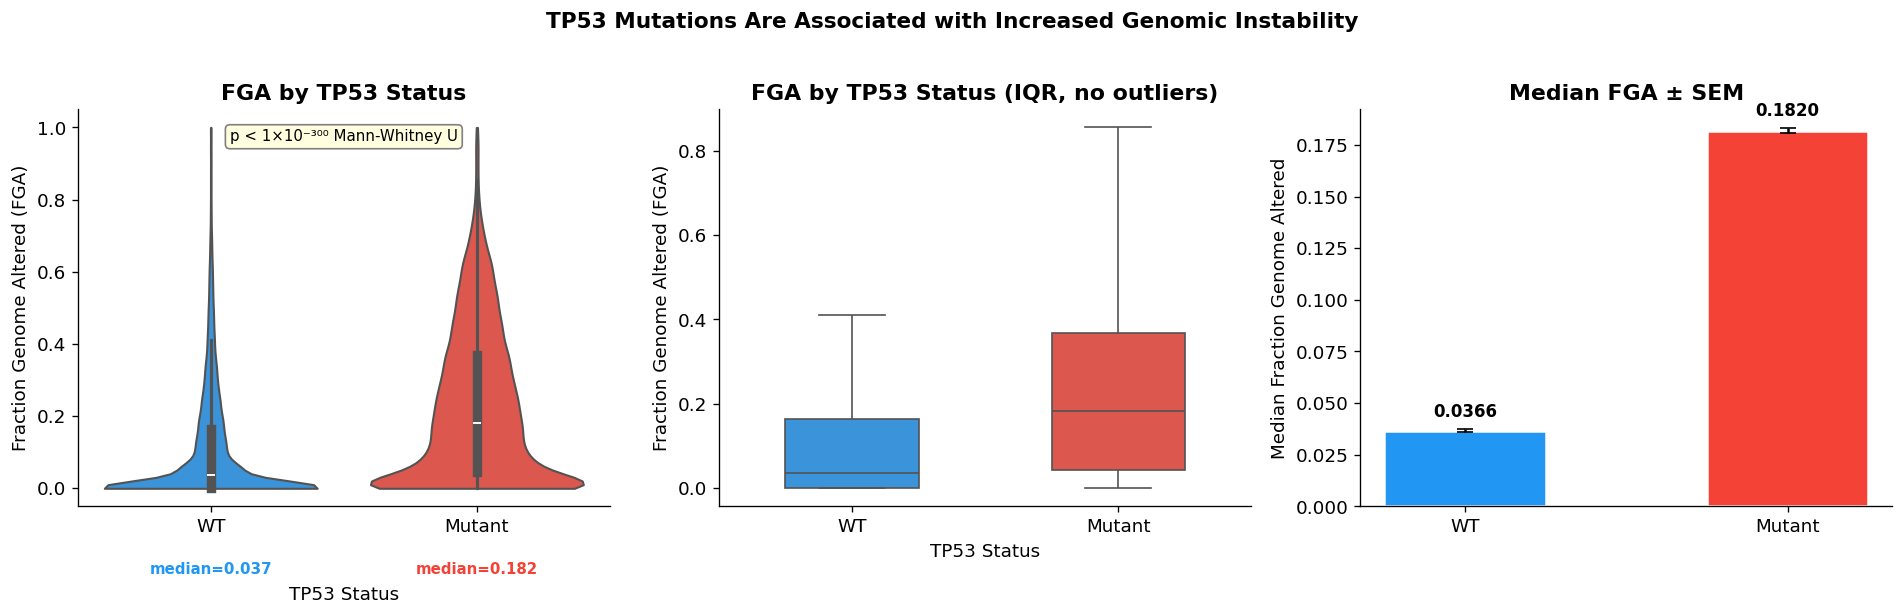

Figure 1 saved.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Panel A: Violin plot ---
ax = axes[0]
plot_data = df_analysis[df_analysis['TP53_mut_simple'].isin(['WT', 'Mutant'])]
order = ['WT', 'Mutant']
palette = [COLORS['WT'], COLORS['Mutant']]

sns.violinplot(data=plot_data, x='TP53_mut_simple', y='FGA',
               order=order, palette=palette,
               inner='box', cut=0, ax=ax)
ax.set_title('FGA by TP53 Status', fontweight='bold')
ax.set_xlabel('TP53 Status', labelpad=30)
ax.set_ylabel('Fraction Genome Altered (FGA)')

# p-value label (handle float underflow gracefully)
pval_str = 'p < 1×10⁻³⁰⁰' if pval == 0.0 else f'p = {pval:.2e}'
ax.annotate(
    f'{pval_str} Mann-Whitney U',
    xy=(0.5, 0.95), xycoords='axes fraction',
    ha='center', va='top', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray')
)

# Add medians as text below the x-axis tick labels
from matplotlib.transforms import blended_transform_factory
trans = blended_transform_factory(ax.transData, ax.transAxes)
for i, (grp, color) in enumerate(zip(order, palette)):
    med = plot_data.loc[plot_data['TP53_mut_simple'] == grp, 'FGA'].median()
    ax.text(i, -0.14, f'median={med:.3f}', ha='center', va='top',
            fontsize=9, color=color, fontweight='bold',
            transform=trans, clip_on=False)

# --- Panel B: Boxplot (zoomed) ---
ax = axes[1]
sns.boxplot(data=plot_data, x='TP53_mut_simple', y='FGA',
            order=order, palette=palette,
            showfliers=False, width=0.5, ax=ax)
ax.set_title('FGA by TP53 Status (IQR, no outliers)', fontweight='bold')
ax.set_xlabel('TP53 Status')
ax.set_ylabel('Fraction Genome Altered (FGA)')

# --- Panel C: Median FGA bar ---
ax = axes[2]
medians = plot_data.groupby('TP53_mut_simple')['FGA'].median().reindex(order)
sems = plot_data.groupby('TP53_mut_simple')['FGA'].sem().reindex(order)
bars = ax.bar(order, medians, color=palette, edgecolor='white', linewidth=1.5, width=0.5)
ax.errorbar(order, medians, yerr=sems, fmt='none', color='black', capsize=5)
ax.set_title('Median FGA ± SEM', fontweight='bold')
ax.set_ylabel('Median Fraction Genome Altered')
for bar, val in zip(bars, medians):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle('TP53 Mutations Are Associated with Increased Genomic Instability',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig1_fga_by_tp53status.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 5. FGA Distribution — Overall

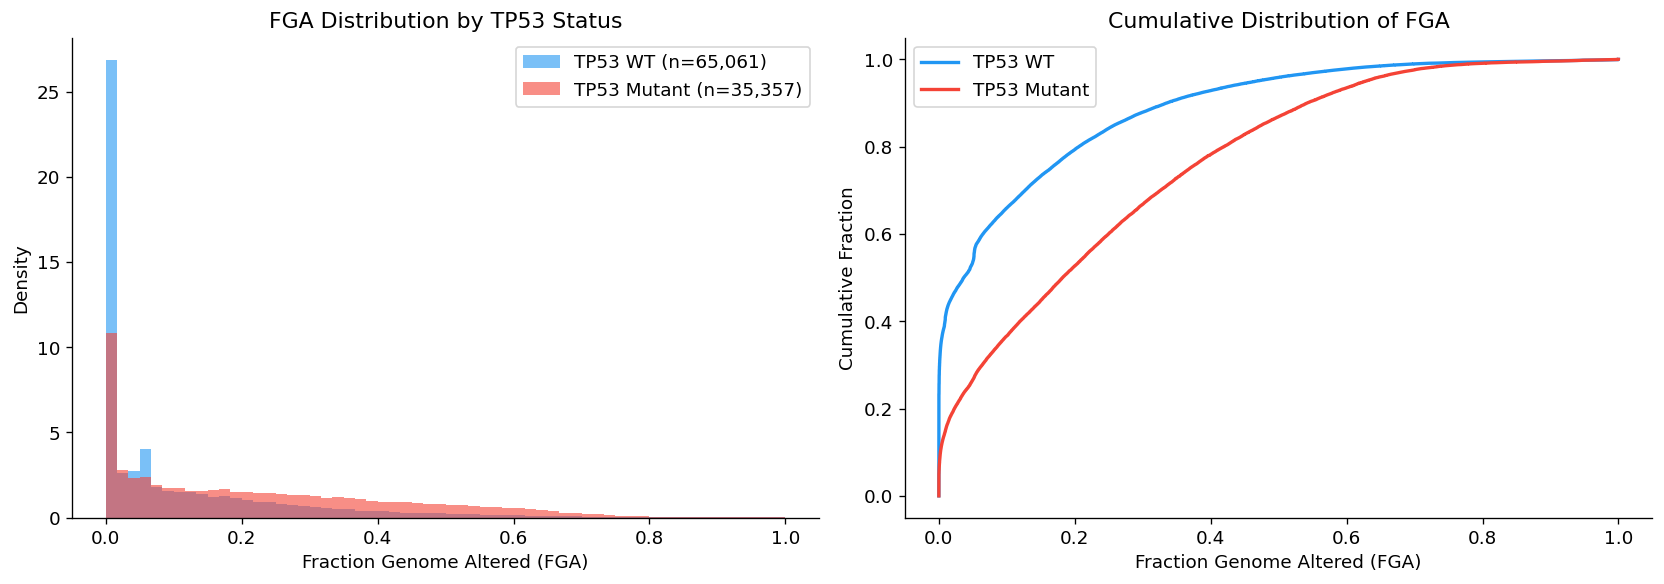

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, color in [('WT', COLORS['WT']), ('Mutant', COLORS['Mutant'])]:
    data = df_analysis.loc[df_analysis['TP53_mut_simple'] == label, 'FGA']
    ax.hist(data, bins=60, alpha=0.6, color=color, label=f'TP53 {label} (n={len(data):,})', density=True)
ax.set_xlabel('Fraction Genome Altered (FGA)')
ax.set_ylabel('Density')
ax.set_title('FGA Distribution by TP53 Status')
ax.legend()

ax = axes[1]
for label, color in [('WT', COLORS['WT']), ('Mutant', COLORS['Mutant'])]:
    data = df_analysis.loc[df_analysis['TP53_mut_simple'] == label, 'FGA'].sort_values()
    ax.plot(data.values, np.linspace(0, 1, len(data)), color=color, label=f'TP53 {label}', linewidth=2)
ax.set_xlabel('Fraction Genome Altered (FGA)')
ax.set_ylabel('Cumulative Fraction')
ax.set_title('Cumulative Distribution of FGA')
ax.legend()

plt.tight_layout()
plt.savefig('figures/fig2_fga_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cancer Type Stratification

In [11]:
# Top cancer types with enough samples in both WT and Mutant groups
min_per_group = 30
counts = df_analysis.groupby(['CANCER_TYPE', 'TP53_mut_simple']).size().unstack(fill_value=0)
eligible = counts[
    (counts.get('WT', pd.Series(dtype=int)) >= min_per_group) &
    (counts.get('Mutant', pd.Series(dtype=int)) >= min_per_group)
].index.tolist()

print(f'Cancer types with >= {min_per_group} samples in both groups: {len(eligible)}')
print(eligible[:20])

Cancer types with >= 30 samples in both groups: 39
['Adrenocortical Carcinoma', 'Ampullary Cancer', 'Appendiceal Cancer', 'B-Lymphoblastic Leukemia/Lymphoma', 'Bladder Cancer', 'Blood Cancer, NOS', 'Bone Cancer', 'Breast Cancer', 'Cancer of Unknown Primary', 'Cervical Cancer', 'Colorectal Cancer', 'Endometrial Cancer', 'Esophagogastric Cancer', 'Gastrointestinal Neuroendocrine Tumor', 'Gastrointestinal Stromal Tumor', 'Germ Cell Tumor', 'Glioma', 'Head and Neck Cancer', 'Hepatobiliary Cancer', 'Leukemia']


In [12]:
# Per-cancer-type statistics
results = []
for cancer in eligible:
    sub = df_analysis[df_analysis['CANCER_TYPE'] == cancer]
    wt   = sub.loc[sub['TP53_mut_simple'] == 'WT', 'FGA'].dropna()
    mut  = sub.loc[sub['TP53_mut_simple'] == 'Mutant', 'FGA'].dropna()
    if len(wt) < 5 or len(mut) < 5:
        continue
    stat_u, p = mannwhitneyu(mut, wt, alternative='greater')
    results.append({
        'Cancer Type': cancer,
        'n_WT': len(wt),
        'n_Mutant': len(mut),
        'median_FGA_WT': wt.median(),
        'median_FGA_Mutant': mut.median(),
        'FGA_fold_change': mut.median() / wt.median() if wt.median() > 0 else np.nan,
        'p_value': p
    })

cancer_stats = pd.DataFrame(results)

# FDR correction (Benjamini-Hochberg)
from scipy.stats import false_discovery_control
cancer_stats['p_adj'] = false_discovery_control(cancer_stats['p_value'])
cancer_stats['significant'] = cancer_stats['p_adj'] < 0.05

cancer_stats = cancer_stats.sort_values('FGA_fold_change', ascending=False)
print(f'Cancer types tested: {len(cancer_stats)}')
print(f'Significant (FDR < 0.05): {cancer_stats["significant"].sum()}')
print()
print(cancer_stats.head(15).to_string(index=False))

Cancer types tested: 39
Significant (FDR < 0.05): 35

                          Cancer Type  n_WT  n_Mutant  median_FGA_WT  median_FGA_Mutant  FGA_fold_change       p_value         p_adj  significant
                    Blood Cancer, NOS   332        54        0.00015            0.03185       212.333333  6.783827e-10  1.556290e-09         True
                             Leukemia  4766       619        0.00050            0.05280       105.600000  2.212323e-90  1.232580e-89         True
            Myelodysplastic Syndromes  1749       236        0.00030            0.02310        77.000000  3.537165e-16  9.853530e-16         True
    B-Lymphoblastic Leukemia/Lymphoma   671        94        0.00100            0.04985        49.850000  1.441142e-08  2.676407e-08         True
            Mature T and NK Neoplasms   878       123        0.00150            0.06960        46.400000  1.866592e-14  4.549819e-14         True
                   Appendiceal Cancer   329       114        0.00170  

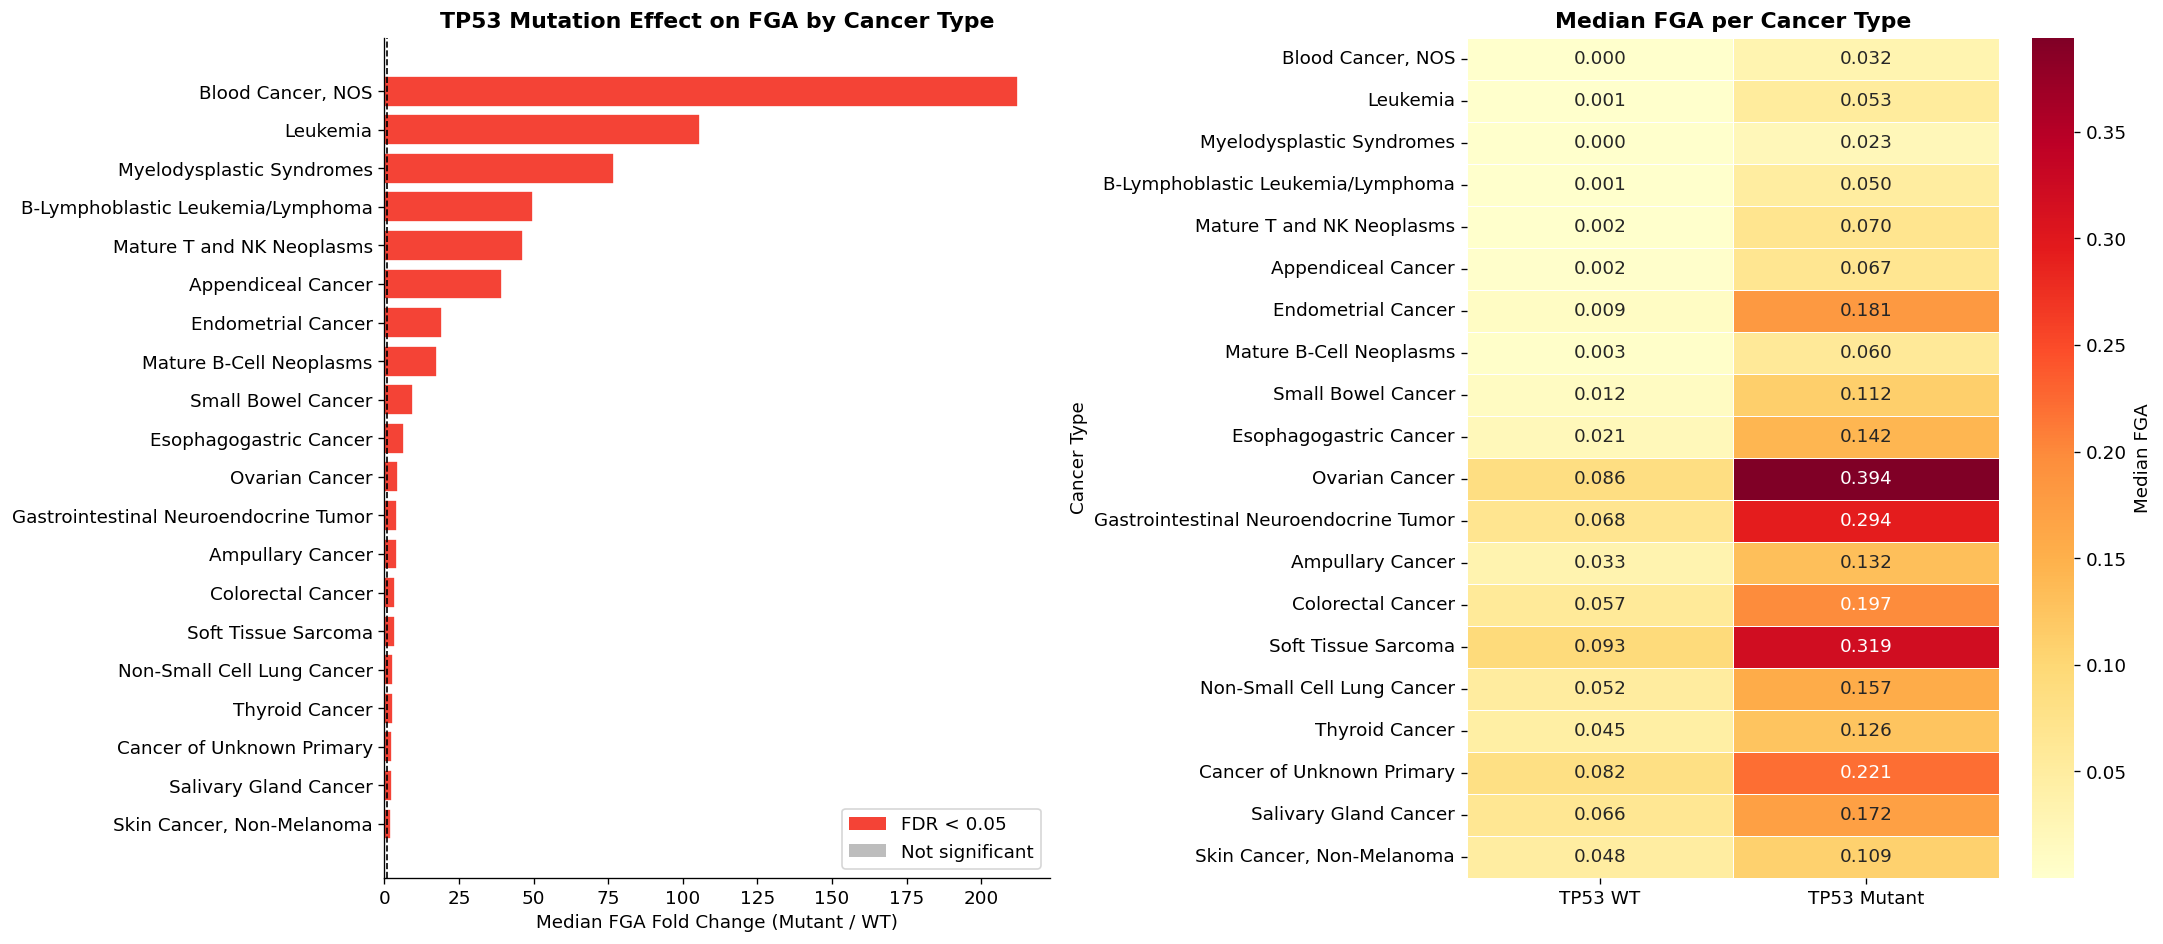

In [13]:
# Plot: top 20 cancer types by fold change
top_cancers = cancer_stats.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: FGA fold change per cancer type
ax = axes[0]
colors_bar = ['#F44336' if sig else '#BDBDBD' for sig in top_cancers['significant']]
bars = ax.barh(top_cancers['Cancer Type'], top_cancers['FGA_fold_change'],
               color=colors_bar, edgecolor='white')
ax.axvline(x=1, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Median FGA Fold Change (Mutant / WT)')
ax.set_title('TP53 Mutation Effect on FGA by Cancer Type', fontweight='bold')
ax.invert_yaxis()
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#F44336', label='FDR < 0.05'),
                   Patch(facecolor='#BDBDBD', label='Not significant')]
ax.legend(handles=legend_elements, loc='lower right')

# Right: heatmap of median FGA
ax = axes[1]
heatmap_data = top_cancers.set_index('Cancer Type')[['median_FGA_WT', 'median_FGA_Mutant']]
heatmap_data.columns = ['TP53 WT', 'TP53 Mutant']
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.3f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Median FGA'})
ax.set_title('Median FGA per Cancer Type', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/fig3_cancer_type_fga.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. CNA Burden Analysis

In [14]:
# CNA burden: from cna.txt
# Values: 0=neutral, -1=shallow deletion, -2=deep deletion, 1=low amp, 2=high amp, NP=not profiled

cna_burden = cna_clean.copy()
cna_burden['TP53_CNA_num'] = pd.to_numeric(cna_burden['TP53_CNA'], errors='coerce')

# Classify CNA type for TP53 locus
def classify_cna(val):
    if pd.isna(val): return 'Not Profiled'
    elif val == 0:   return 'Neutral'
    elif val == -1:  return 'Shallow Del'
    elif val <= -2:  return 'Deep Del'
    elif val == 1:   return 'Low Amp'
    elif val >= 2:   return 'High Amp'
    else:            return 'Other'

cna_burden['TP53_CNA_class'] = cna_burden['TP53_CNA_num'].apply(classify_cna)

# Merge with FGA and TP53 mutation status
cna_fga = cna_burden.merge(
    df_analysis[['SAMPLE_ID', 'FGA', 'TP53_mut_simple', 'CANCER_TYPE']],
    on='SAMPLE_ID', how='inner'
)

print('CNA class distribution for TP53 locus:')
print(cna_fga['TP53_CNA_class'].value_counts())

CNA class distribution for TP53 locus:
TP53_CNA_class
Neutral     99139
Deep Del     1209
High Amp       70
Name: count, dtype: int64


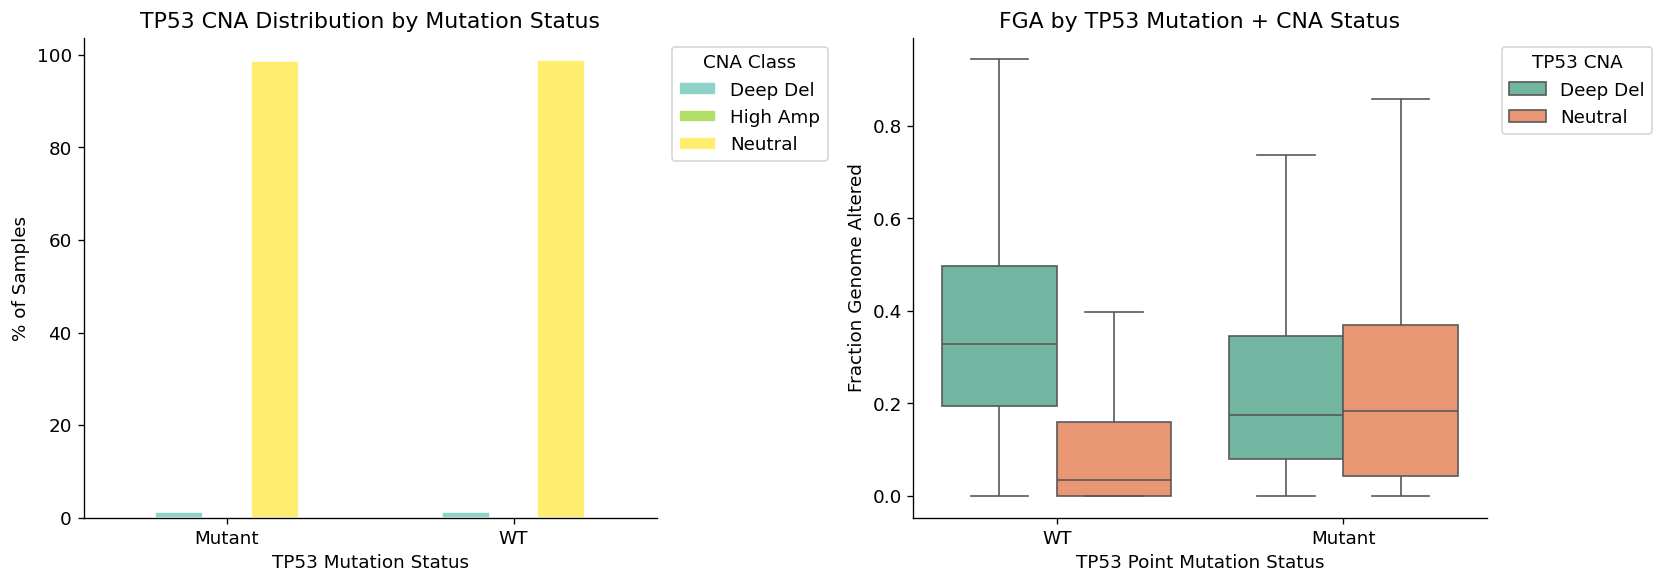

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: TP53 CNA class distribution by mutation status
ax = axes[0]
cna_cross = cna_fga[cna_fga['TP53_mut_simple'].isin(['WT', 'Mutant'])].copy()
cna_cross = cna_cross[cna_cross['TP53_CNA_class'] != 'Not Profiled']
ct = pd.crosstab(cna_cross['TP53_mut_simple'], cna_cross['TP53_CNA_class'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, colormap='Set3', edgecolor='white')
ax.set_xlabel('TP53 Mutation Status')
ax.set_ylabel('% of Samples')
ax.set_title('TP53 CNA Distribution by Mutation Status')
ax.legend(title='CNA Class', bbox_to_anchor=(1.01, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Right: FGA by TP53 CNA class (combined with mutation)
ax = axes[1]
cna_fga_sub = cna_cross[cna_cross['TP53_CNA_class'].isin(['Deep Del', 'Shallow Del', 'Neutral'])]
sns.boxplot(data=cna_fga_sub, x='TP53_mut_simple', y='FGA',
            hue='TP53_CNA_class', showfliers=False, ax=ax,
            palette='Set2')
ax.set_title('FGA by TP53 Mutation + CNA Status')
ax.set_xlabel('TP53 Point Mutation Status')
ax.set_ylabel('Fraction Genome Altered')
ax.legend(title='TP53 CNA', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig('figures/fig4_cna_burden.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Giacomelli Experimental Functional Score (EFS) Computation

**Method**: EFS is derived from CRISPR-based competitive growth screens in A549 p53-null cells.
- Each TP53 variant is expressed in p53-null cells under stress (Nutlin-3, Etoposide)
- Functional variants suppress growth → depleted over time → **higher EFS**
- LOF variants can't suppress growth → stable → **lower EFS**

$$\text{log2FC} = \log_2\frac{\text{stress counts} + 1}{\text{early counts} + 1}$$

EFS = mean log2FC across conditions, normalized to synonymous (neutral) variants

In [16]:
# Load Giacomelli with correct headers
gia = giacomelli_raw.copy()
print('Giacomelli columns:')
print(gia.columns.tolist())
print()
print('Variant_group values:')
print(gia['Variant_group'].value_counts().head(10))
print()
print('Sample alleles:', gia['Allele'].head(10).tolist())

Giacomelli columns:
['Allele', 'Position', 'Wt_codon', 'Wt_aa', 'Vt_codon', 'Vt_aa', 'Nucleotide_Changes_from_WT', 'Variant_group', 'TP53_MITE_Entry_Library', 'TP53_MITE_Expression_Library', 'A549_p53WT_Early_Time_Point_Experiment_1', 'A549_p53WT_Early_Time_Point_Experiment_2', 'A549_p53WT_Nutlin-3_Experiment_1', 'A549_p53WT_Nutlin-3_Experiment_2', 'A549_p53NULL_Early_Time_Point_Experiment_1', 'A549_p53NULL_Early_Time_Point_Experiment_2', 'A549_p53NULL_Nutlin-3_Experiment_1', 'A549_p53NULL_Nutlin-3_Experiment_2', 'A549_p53NULL_Etoposide_Experiment_1', 'A549_p53NULL_Etoposide_Experiment_2']

Variant_group values:
Variant_group
Unintended         16927
IntendedVtCodon     7859
BackboneWt           394
IntendedWtCodon       37
Name: count, dtype: int64

Sample alleles: ['M1M', 'E2E', 'E3E', 'P4P', 'Q5Q', 'S6S', 'D7D', 'P8P', 'S9S', 'V10V']


In [17]:
# Define column groups for EFS computation
early_cols = [
    'A549_p53NULL_Early_Time_Point_Experiment_1',
    'A549_p53NULL_Early_Time_Point_Experiment_2'
]
stress_cols = [
    'A549_p53NULL_Nutlin-3_Experiment_1',
    'A549_p53NULL_Nutlin-3_Experiment_2',
    'A549_p53NULL_Etoposide_Experiment_1',
    'A549_p53NULL_Etoposide_Experiment_2'
]

# Only work with rows that have count data (numeric in early cols)
gia_counts = gia.copy()
for col in early_cols + stress_cols:
    gia_counts[col] = pd.to_numeric(gia_counts[col], errors='coerce')

gia_counts = gia_counts.dropna(subset=early_cols + stress_cols)
print('Rows with count data:', len(gia_counts))

# Compute mean early counts
gia_counts['early_mean'] = gia_counts[early_cols].mean(axis=1)

# Compute log2FC for each stress condition vs mean early
for col in stress_cols:
    gia_counts[f'log2FC_{col}'] = np.log2(
        (gia_counts[col] + 1) / (gia_counts['early_mean'] + 1)
    )

log2fc_cols = [f'log2FC_{c}' for c in stress_cols]

# Mean log2FC across all stress conditions
gia_counts['mean_log2FC'] = gia_counts[log2fc_cols].mean(axis=1)

print('\nVariant groups:')
print(gia_counts['Variant_group'].value_counts())

Rows with count data: 25217

Variant groups:
Variant_group
Unintended         16927
IntendedVtCodon     7859
BackboneWt           394
IntendedWtCodon       37
Name: count, dtype: int64


In [18]:
# Normalize to synonymous variants (neutral controls)
# Identify synonymous: Wt_aa == Vt_aa  OR  Variant_group contains 'synonymous'/'Synonymous'
syn_mask = (
    (gia_counts['Wt_aa'] == gia_counts['Vt_aa']) |
    (gia_counts['Variant_group'].str.lower().str.contains('syn', na=False))
)
print('Synonymous variants identified:', syn_mask.sum())

syn_mean = gia_counts.loc[syn_mask, 'mean_log2FC'].mean()
syn_std  = gia_counts.loc[syn_mask, 'mean_log2FC'].std()
print(f'Synonymous mean log2FC = {syn_mean:.4f}, std = {syn_std:.4f}')

# EFS = (log2FC - synonymous_mean) / synonymous_std  (z-score normalization)
# Positive EFS = more functional than synonymous baseline
# Negative EFS = less functional (LOF)
gia_counts['EFS'] = (gia_counts['mean_log2FC'] - syn_mean) / syn_std

print('\nEFS distribution:')
print(gia_counts['EFS'].describe().round(3))
print()
print('EFS by variant group:')
print(gia_counts.groupby('Variant_group')['EFS'].median().sort_values(ascending=False).round(3))

Synonymous variants identified: 1431
Synonymous mean log2FC = 0.1292, std = 0.2703

EFS distribution:
count    25217.000
mean        -0.486
std          1.907
min        -11.578
25%         -1.403
50%         -0.235
75%          0.512
max         10.765
Name: EFS, dtype: float64

EFS by variant group:
Variant_group
IntendedWtCodon    0.197
BackboneWt         0.112
IntendedVtCodon    0.027
Unintended        -0.478
Name: EFS, dtype: float64


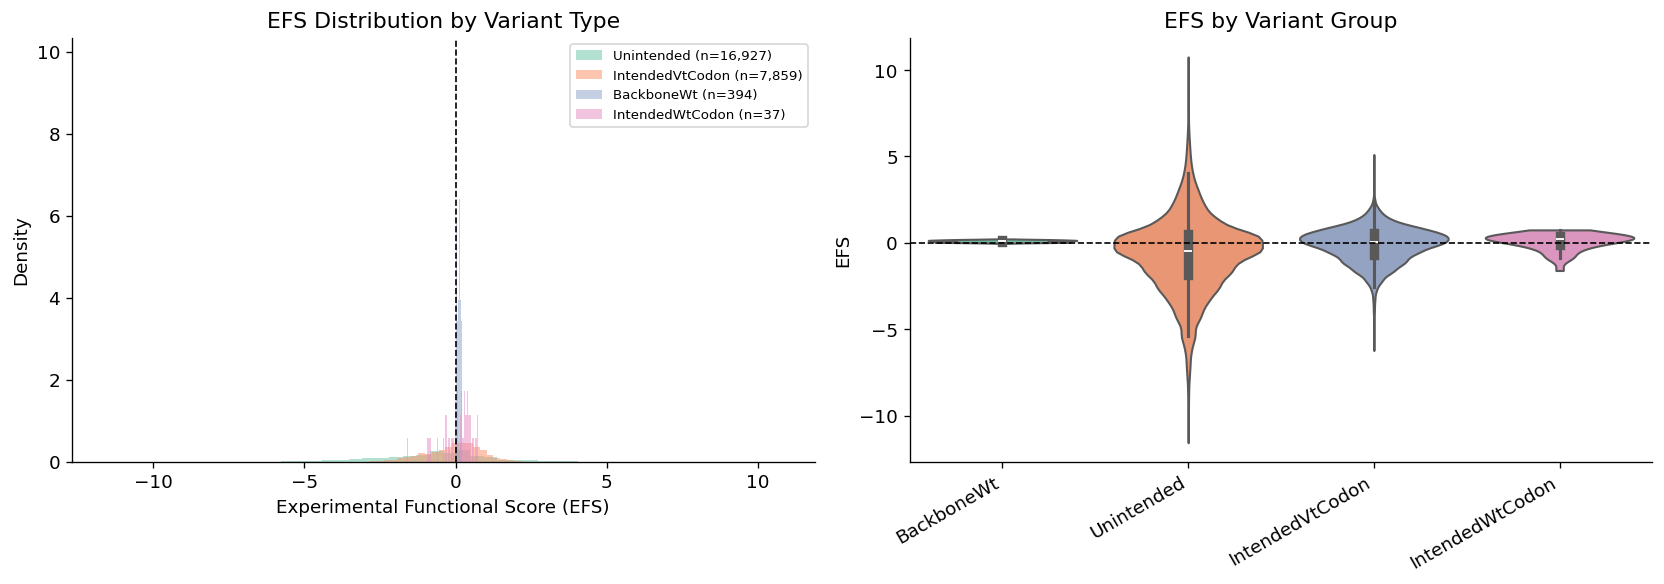

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: EFS distribution by variant group
ax = axes[0]
variant_groups = gia_counts['Variant_group'].value_counts().head(5).index.tolist()
for vg in variant_groups:
    data = gia_counts.loc[gia_counts['Variant_group'] == vg, 'EFS']
    ax.hist(data, bins=50, alpha=0.5, label=f'{vg} (n={len(data):,})', density=True)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Experimental Functional Score (EFS)')
ax.set_ylabel('Density')
ax.set_title('EFS Distribution by Variant Type')
ax.legend(fontsize=8)

# Right: Violin per variant group
ax = axes[1]
gia_plot = gia_counts[gia_counts['Variant_group'].isin(variant_groups)]
sns.violinplot(data=gia_plot, x='Variant_group', y='EFS', inner='box', cut=0,
               palette='Set2', ax=ax)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title('EFS by Variant Group')
ax.set_xlabel('')
ax.set_ylabel('EFS')

plt.tight_layout()
plt.savefig('figures/fig5_giacomelli_efs.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Mapping GENIE Mutations to Giacomelli EFS

GENIE mutation names follow the format: `R175H` (reference AA + position + variant AA).  
We match these to Giacomelli alleles (`Allele` column, same format).

In [20]:
# Giacomelli EFS per allele (aggregate over codons at same aa position)
# Allele format: e.g. 'R175H' = Arg175His
# Aggregate: for each Allele, take the median EFS (multiple codon paths to same AA change)

# Build EFS lookup: Allele → median EFS
efs_lookup = (
    gia_counts
    .groupby('Allele')['EFS']
    .median()
    .reset_index()
    .rename(columns={'Allele': 'TP53_mutation', 'EFS': 'EFS_score'})
)

print(f'Unique alleles with EFS: {len(efs_lookup)}')
print('Sample alleles:', efs_lookup['TP53_mutation'].head(10).tolist())

# GENIE mutation names for mutant samples
genie_muts = df_analysis[df_analysis['TP53_mut_simple'] == 'Mutant'][['SAMPLE_ID', 'TP53_mutation', 'FGA', 'CANCER_TYPE']].copy()
print(f'\nGENIE TP53-mutant samples: {len(genie_muts)}')
print('GENIE mutation examples:', genie_muts['TP53_mutation'].head(10).tolist())

Unique alleles with EFS: 8274
Sample alleles: ['A119A', 'A119C', 'A119D', 'A119E', 'A119F', 'A119G', 'A119H', 'A119I', 'A119K', 'A119L']

GENIE TP53-mutant samples: 35357
GENIE mutation examples: ['C135F', 'S127F', 'I255N', 'W146*', 'D186N', 'L194F', 'R248G', 'L330Ffs*15', 'X307_splice', 'I332Tfs*13']


In [21]:
# Direct merge by allele name
genie_efs = genie_muts.merge(efs_lookup, on='TP53_mutation', how='left')

n_matched = genie_efs['EFS_score'].notna().sum()
print(f'GENIE mutations matched to EFS: {n_matched:,} / {len(genie_efs):,} ({100*n_matched/len(genie_efs):.1f}%)')

# Top unmatched mutations
unmatched = genie_efs[genie_efs['EFS_score'].isna()]['TP53_mutation'].value_counts().head(10)
print('\nTop unmatched GENIE mutations:')
print(unmatched)

GENIE mutations matched to EFS: 20,891 / 35,357 (59.1%)

Top unmatched GENIE mutations:
TP53_mutation
R213*          619
R342*          418
R196*          413
X187_splice    351
X307_splice    297
R306*          296
X261_splice    258
X126_splice    248
X125_splice    182
X225_splice    181
Name: count, dtype: int64


In [22]:
# For unmatched: try position-based matching
# Unmatched types: splice variants (X187_splice), truncations (R213*), etc.
# We can try to parse the protein position and look up the EFS

import re

def parse_mutation(mut_str):
    """Extract (ref_aa, position, var_aa) from a mutation string like R175H, R213*, etc."""
    mut_str = str(mut_str).strip()
    m = re.match(r'^([A-Z])([0-9]+)([A-Z*_]+)', mut_str)
    if m:
        return m.group(1), int(m.group(2)), m.group(3)
    return None, None, None

# Build position-based EFS lookup from Giacomelli
gia_counts['parsed_pos'] = pd.to_numeric(gia_counts['Position'], errors='coerce')
efs_by_position = (
    gia_counts
    .groupby('parsed_pos')['EFS']
    .median()
    .reset_index()
    .rename(columns={'parsed_pos': 'position', 'EFS': 'EFS_by_pos'})
)

# Try to fill unmatched by position
genie_efs[['ref_aa', 'mut_pos', 'var_aa']] = genie_efs['TP53_mutation'].apply(
    lambda x: pd.Series(parse_mutation(x))
)

genie_efs = genie_efs.merge(efs_by_position, left_on='mut_pos', right_on='position', how='left')

# Use position-based EFS where direct match is missing
genie_efs['EFS_final'] = genie_efs['EFS_score'].fillna(genie_efs['EFS_by_pos'])

n_matched_final = genie_efs['EFS_final'].notna().sum()
print(f'Matched after position fallback: {n_matched_final:,} / {len(genie_efs):,} ({100*n_matched_final/len(genie_efs):.1f}%)')

Matched after position fallback: 35,000 / 35,357 (99.0%)


## 10. Core Hypothesis: EFS vs FGA Correlation

In [23]:
# Use samples with both EFS and FGA
efs_fga = genie_efs.dropna(subset=['EFS_final', 'FGA']).copy()
print(f'Samples for EFS-FGA correlation: {len(efs_fga):,}')

# Spearman correlation: EFS vs FGA
rho, p_corr = spearmanr(efs_fga['EFS_final'], efs_fga['FGA'])
print(f'Spearman rho = {rho:.4f}, p = {p_corr:.2e}')
print()
print('Hypothesis check:')
print('  LOWEST EFS → HIGHEST FGA?')
if rho < 0:
    print(f'  YES: negative correlation (rho={rho:.3f}) — lower EFS associated with higher FGA')
else:
    print(f'  Positive correlation (rho={rho:.3f}) — review EFS sign convention')

Samples for EFS-FGA correlation: 35,000
Spearman rho = 0.0136, p = 1.10e-02

Hypothesis check:
  LOWEST EFS → HIGHEST FGA?
  Positive correlation (rho=0.014) — review EFS sign convention


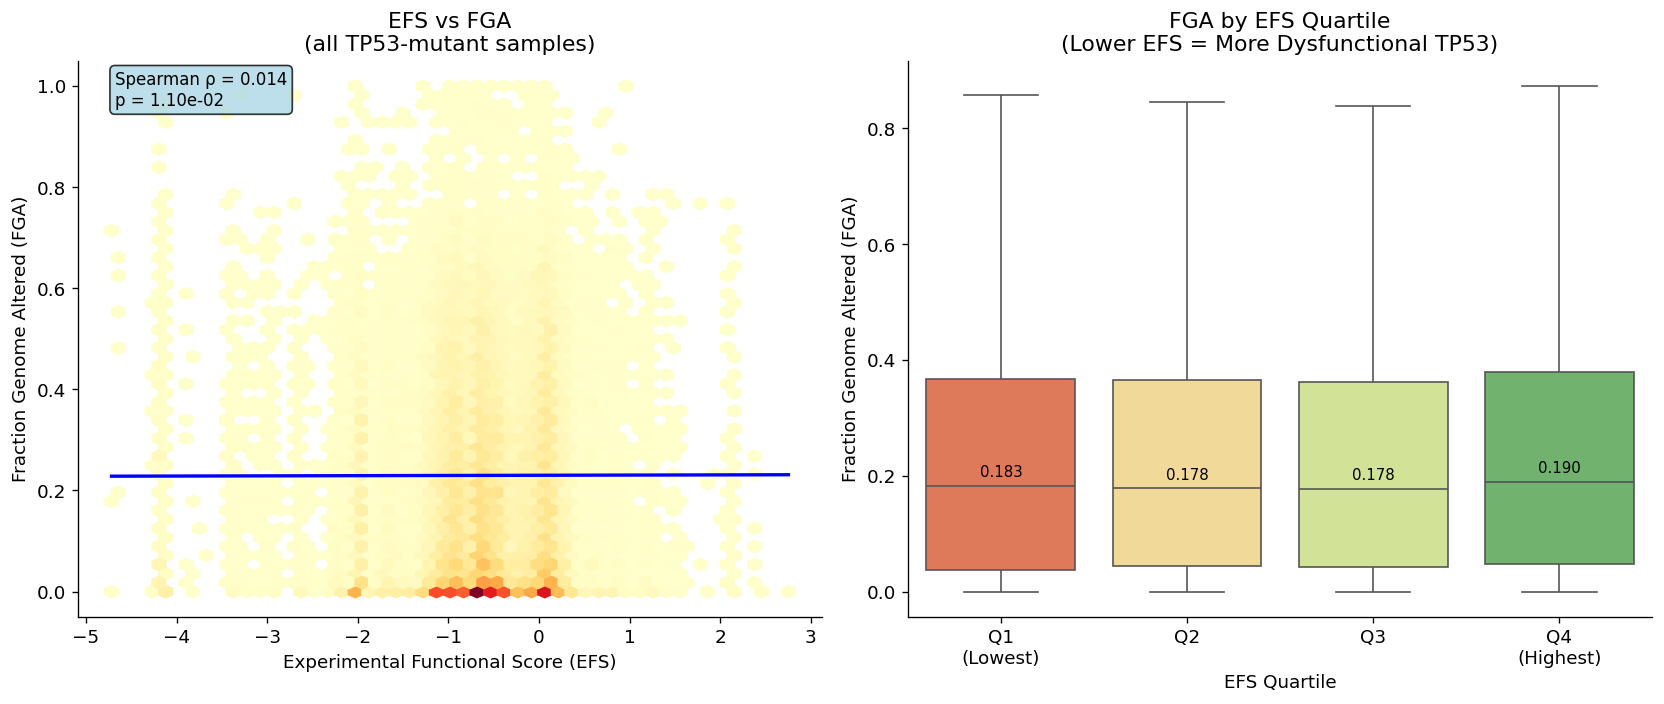

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Scatter plot EFS vs FGA
ax = axes[0]
ax.hexbin(efs_fga['EFS_final'], efs_fga['FGA'],
          gridsize=50, cmap='YlOrRd', mincnt=1)
ax.set_xlabel('Experimental Functional Score (EFS)')
ax.set_ylabel('Fraction Genome Altered (FGA)')
ax.set_title('EFS vs FGA\n(all TP53-mutant samples)')

# Add regression line
from numpy.polynomial.polynomial import polyfit
x_clean = efs_fga['EFS_final'].values
y_clean = efs_fga['FGA'].values
b = np.polyfit(x_clean, y_clean, 1)
x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
ax.plot(x_line, np.polyval(b, x_line), 'b-', linewidth=2, label='Linear fit')
ax.annotate(f'Spearman ρ = {rho:.3f}\np = {p_corr:.2e}',
            xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Right: Binned EFS quartiles vs FGA
ax = axes[1]
efs_fga['EFS_quartile'] = pd.qcut(efs_fga['EFS_final'], q=4,
                                    labels=['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4\n(Highest)'])
order_q = ['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4\n(Highest)']
sns.boxplot(data=efs_fga, x='EFS_quartile', y='FGA',
            order=order_q, palette='RdYlGn',
            showfliers=False, ax=ax)
ax.set_xlabel('EFS Quartile')
ax.set_ylabel('Fraction Genome Altered (FGA)')
ax.set_title('FGA by EFS Quartile\n(Lower EFS = More Dysfunctional TP53)')

# Add median labels
for i, q in enumerate(order_q):
    med = efs_fga.loc[efs_fga['EFS_quartile'] == q, 'FGA'].median()
    ax.text(i, med + 0.01, f'{med:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig6_efs_fga_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# Kruskal-Wallis test across EFS quartiles
groups = [efs_fga.loc[efs_fga['EFS_quartile'] == q, 'FGA'].values for q in order_q]
kw_stat, kw_p = kruskal(*groups)
print(f'Kruskal-Wallis across EFS quartiles: H = {kw_stat:.2f}, p = {kw_p:.2e}')
print()
print('Median FGA per EFS quartile:')
print(efs_fga.groupby('EFS_quartile')['FGA'].median().round(4))

Kruskal-Wallis across EFS quartiles: H = 15.91, p = 1.18e-03

Median FGA per EFS quartile:
EFS_quartile
Q1\n(Lowest)     0.1829
Q2               0.1784
Q3               0.1778
Q4\n(Highest)    0.1899
Name: FGA, dtype: float64


## 11. Hotspot Mutation Analysis

In [26]:
# Hotspot definition: top-frequency mutations in GENIE
mut_counts = mutations_clean[mutations_clean['TP53_mutation'] != 'WT']['TP53_mutation'].value_counts()
top_hotspots = mut_counts[mut_counts >= 500].index.tolist()
print(f'Hotspot mutations (≥500 samples): {len(top_hotspots)}')
print(mut_counts.head(15))

Hotspot mutations (≥500 samples): 26
TP53_mutation
R175H          4292
R248Q          2849
R273H          2677
R273C          2592
R248W          2381
R282W          2050
R213*          1786
NP             1753
Y220C          1473
G245S          1327
R196*          1251
R342*          1212
X187_splice     971
R306*           910
X307_splice     740
Name: count, dtype: int64


In [27]:
# Classify mutations as hotspot vs rare
df_mutants = df_analysis[df_analysis['TP53_mut_simple'] == 'Mutant'].copy()
df_mutants['hotspot'] = df_mutants['TP53_mutation'].isin(top_hotspots)
df_mutants['mutation_class'] = df_mutants['hotspot'].map({True: 'Hotspot', False: 'Rare'})

print('Hotspot samples:', df_mutants['hotspot'].sum())
print('Rare samples:   ', (~df_mutants['hotspot']).sum())

# Test
hs_fga = df_mutants.loc[df_mutants['hotspot'], 'FGA'].dropna()
rare_fga = df_mutants.loc[~df_mutants['hotspot'], 'FGA'].dropna()
stat_hs, p_hs = mannwhitneyu(hs_fga, rare_fga, alternative='two-sided')
print(f'\nHotspot median FGA: {hs_fga.median():.4f}')
print(f'Rare median FGA:    {rare_fga.median():.4f}')
print(f'Mann-Whitney U: p = {p_hs:.2e}')

Hotspot samples: 11472
Rare samples:    23885

Hotspot median FGA: 0.1830
Rare median FGA:    0.1814
Mann-Whitney U: p = 7.92e-01


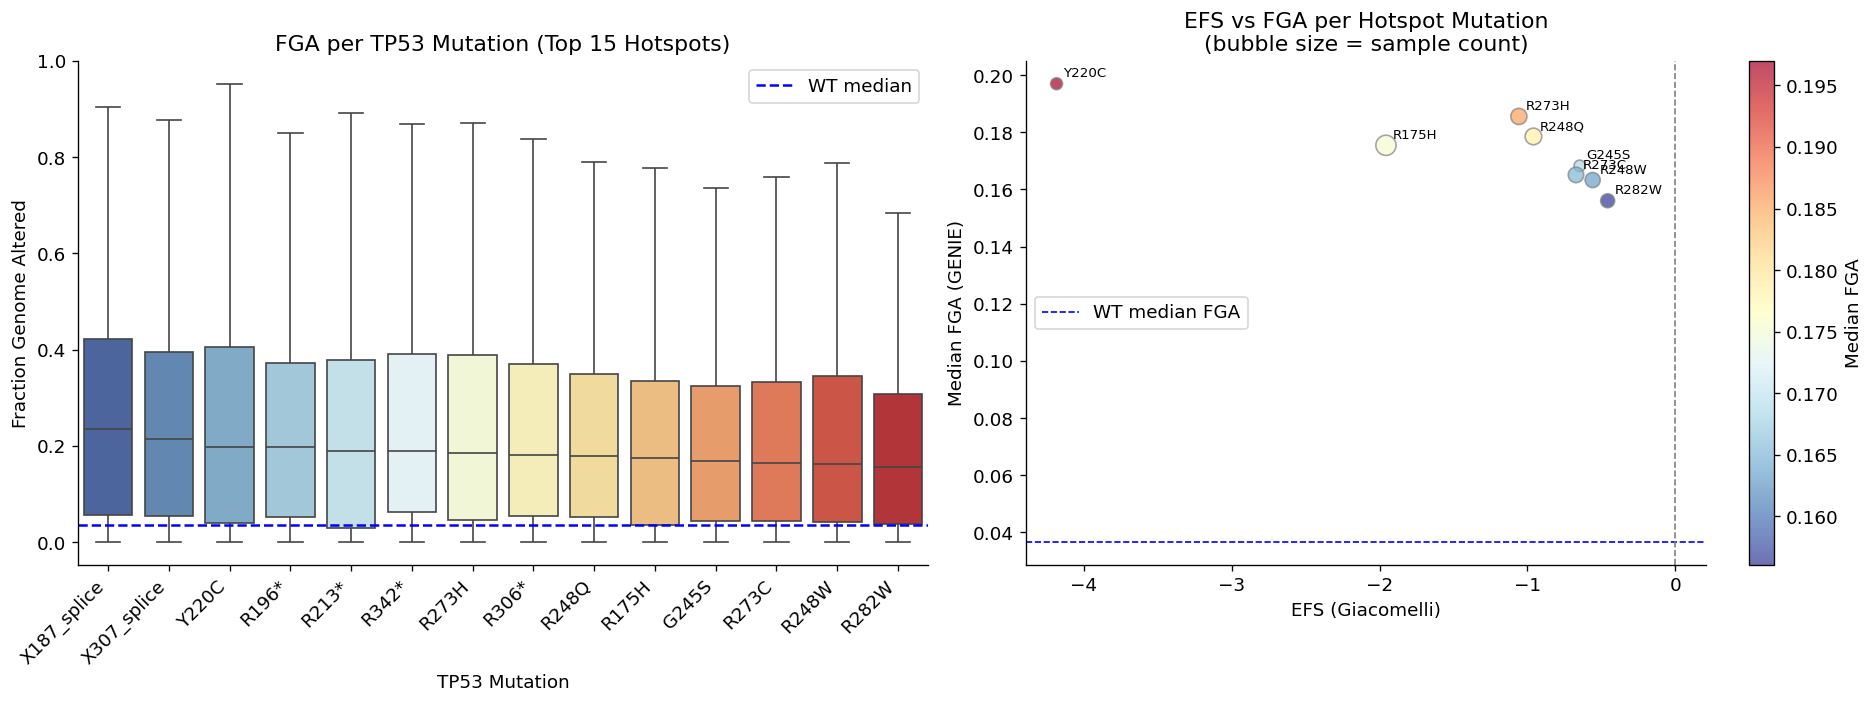

In [28]:
# Plot per-mutation FGA for top hotspot mutations
top15_muts = mut_counts.head(15).index.tolist()
df_top = df_analysis[df_analysis['TP53_mutation'].isin(top15_muts)].copy()

# Add EFS scores
df_top = df_top.merge(efs_lookup.rename(columns={'EFS_score': 'EFS'}), on='TP53_mutation', how='left')

# Sort by median FGA
mut_order = df_top.groupby('TP53_mutation')['FGA'].median().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Boxplot per mutation
ax = axes[0]
sns.boxplot(data=df_top, x='TP53_mutation', y='FGA', order=mut_order,
            palette='RdYlBu_r', showfliers=False, ax=ax)
ax.axhline(y=wt_fga.median(), color='blue', linestyle='--', linewidth=1.5, label='WT median')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('FGA per TP53 Mutation (Top 15 Hotspots)')
ax.set_xlabel('TP53 Mutation')
ax.set_ylabel('Fraction Genome Altered')
ax.legend()

# Right: EFS vs count bubble chart
ax = axes[1]
mut_summary = df_top.groupby('TP53_mutation').agg(
    median_FGA=('FGA', 'median'),
    n=('FGA', 'count'),
    EFS=('EFS', 'first')
).reset_index()

scatter = ax.scatter(
    mut_summary['EFS'], mut_summary['median_FGA'],
    s=mut_summary['n'] / 10, alpha=0.7,
    c=mut_summary['median_FGA'], cmap='RdYlBu_r', edgecolors='gray'
)
plt.colorbar(scatter, ax=ax, label='Median FGA')

for _, row in mut_summary.iterrows():
    ax.annotate(row['TP53_mutation'], (row['EFS'], row['median_FGA']),
                textcoords='offset points', xytext=(4, 4), fontsize=8)

ax.axhline(y=wt_fga.median(), color='blue', linestyle='--', linewidth=1, label='WT median FGA')
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('EFS (Giacomelli)')
ax.set_ylabel('Median FGA (GENIE)')
ax.set_title('EFS vs FGA per Hotspot Mutation\n(bubble size = sample count)')
ax.legend()

plt.tight_layout()
plt.savefig('figures/fig7_hotspot_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. EFS-FGA Correlation by Cancer Type

In [29]:
# Spearman correlation per cancer type
cancer_corr = []
for cancer in efs_fga['CANCER_TYPE'].dropna().unique():
    sub = efs_fga[efs_fga['CANCER_TYPE'] == cancer].dropna(subset=['EFS_final', 'FGA'])
    if len(sub) < 30:
        continue
    rho_c, p_c = spearmanr(sub['EFS_final'], sub['FGA'])
    cancer_corr.append({
        'Cancer Type': cancer,
        'n': len(sub),
        'Spearman_rho': rho_c,
        'p_value': p_c
    })

cancer_corr_df = pd.DataFrame(cancer_corr)
cancer_corr_df['p_adj'] = false_discovery_control(cancer_corr_df['p_value'])
cancer_corr_df['significant'] = cancer_corr_df['p_adj'] < 0.05
cancer_corr_df = cancer_corr_df.sort_values('Spearman_rho')

print(f'Cancer types tested for EFS-FGA correlation: {len(cancer_corr_df)}')
print(f'Significant (FDR < 0.05): {cancer_corr_df["significant"].sum()}')
print()
print(cancer_corr_df.to_string(index=False))

Cancer types tested for EFS-FGA correlation: 40
Significant (FDR < 0.05): 0

                          Cancer Type    n  Spearman_rho  p_value    p_adj  significant
                 Renal Cell Carcinoma  160     -0.210556 0.007529 0.158141        False
Gastrointestinal Neuroendocrine Tumor   57     -0.177189 0.187313 0.538554        False
                         Mesothelioma   59     -0.168535 0.201958 0.538554        False
             Adrenocortical Carcinoma   32     -0.167905 0.358320 0.796266        False
    B-Lymphoblastic Leukemia/Lymphoma   93     -0.164701 0.114650 0.422225        False
                      Germ Cell Tumor  111     -0.105584 0.270073 0.635467        False
                   Appendiceal Cancer  113     -0.063324 0.505204 0.918552        False
                             Melanoma  446     -0.061194 0.197075 0.538554        False
                   Endometrial Cancer 1520     -0.060748 0.017854 0.238056        False
       Gastrointestinal Stromal Tumor   48 

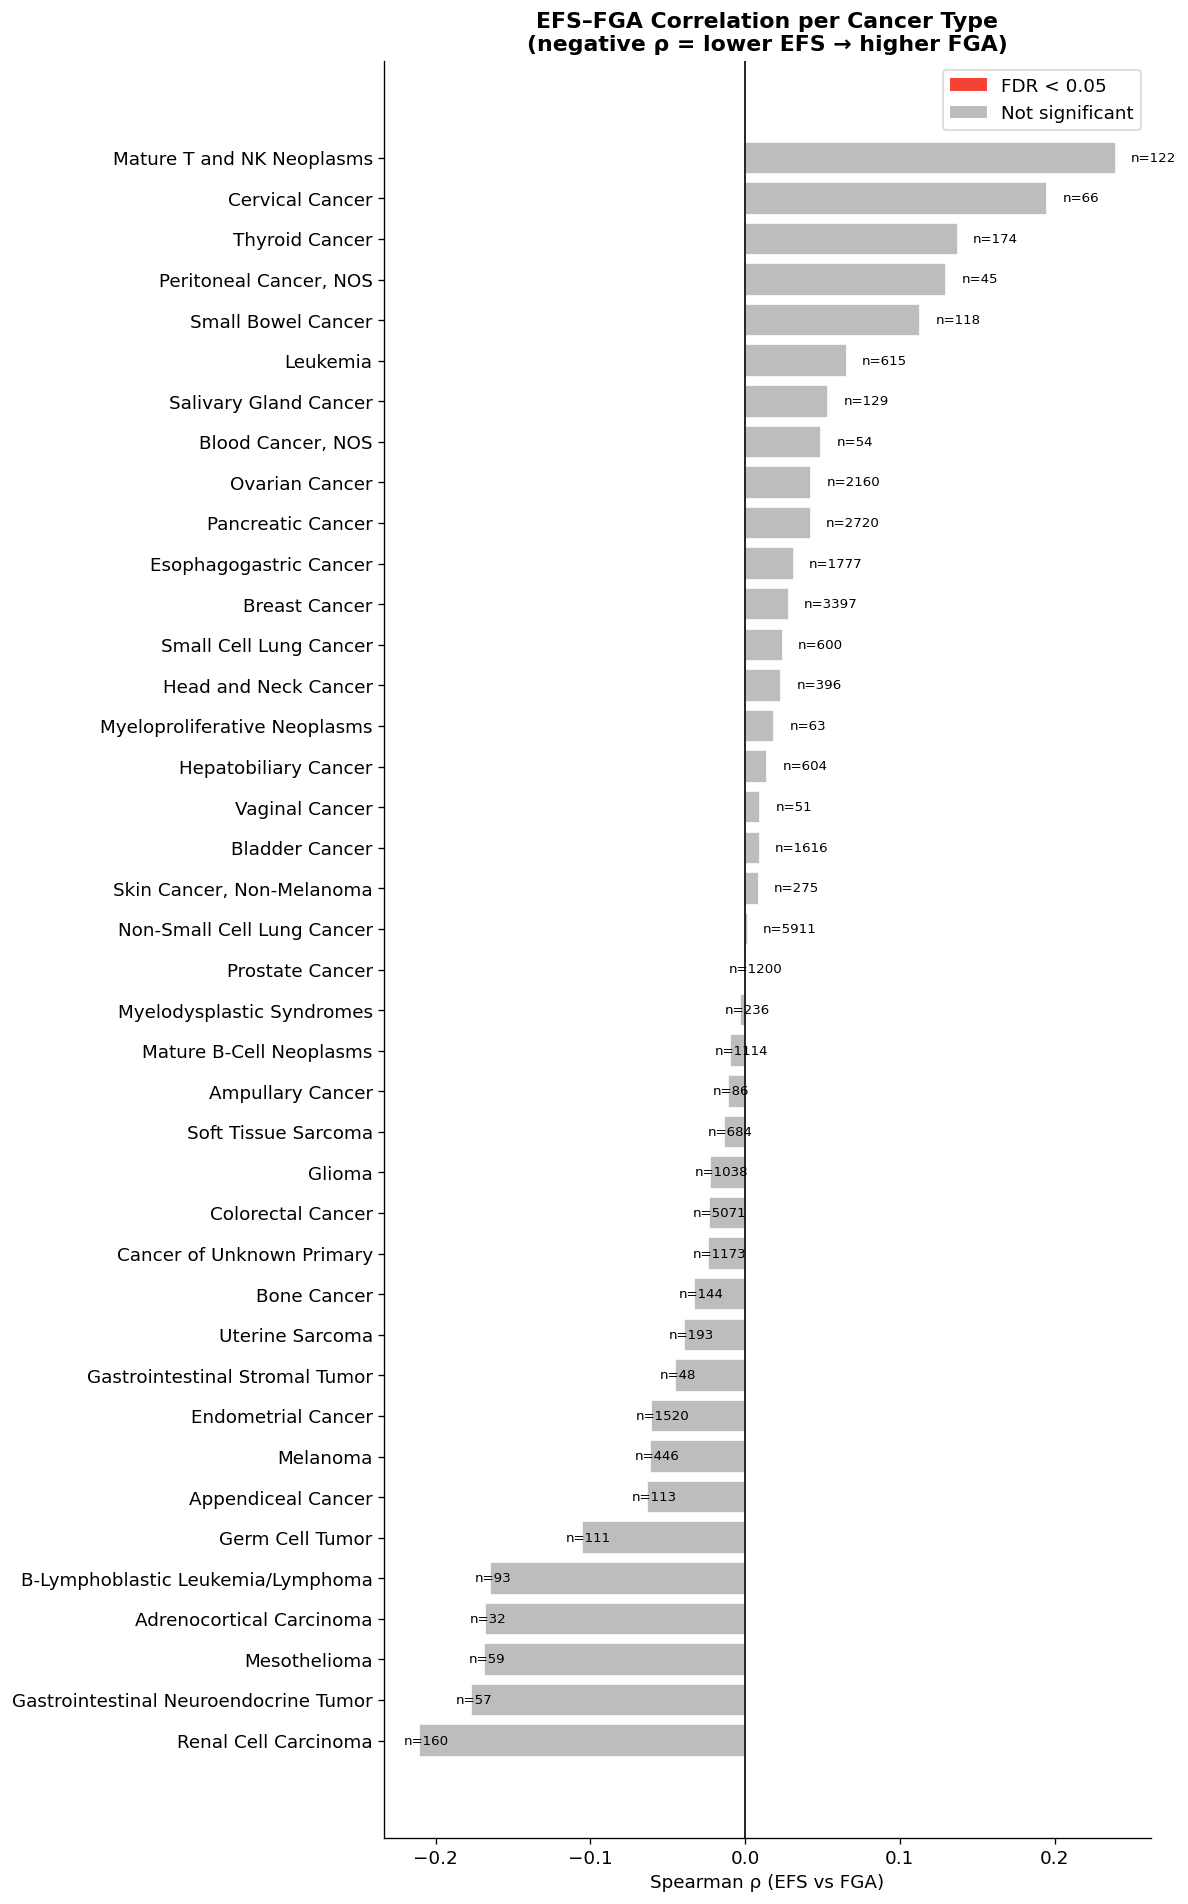

In [30]:
fig, ax = plt.subplots(figsize=(10, max(6, len(cancer_corr_df) * 0.4)))

colors_corr = ['#F44336' if sig else '#BDBDBD' for sig in cancer_corr_df['significant']]
bars = ax.barh(cancer_corr_df['Cancer Type'], cancer_corr_df['Spearman_rho'],
               color=colors_corr, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=1)
ax.set_xlabel('Spearman ρ (EFS vs FGA)')
ax.set_title('EFS–FGA Correlation per Cancer Type\n(negative ρ = lower EFS → higher FGA)', fontweight='bold')

legend_elements = [Patch(facecolor='#F44336', label='FDR < 0.05'),
                   Patch(facecolor='#BDBDBD', label='Not significant')]
ax.legend(handles=legend_elements)

# Sample size annotation
for _, row in cancer_corr_df.iterrows():
    xpos = row['Spearman_rho'] + (0.01 if row['Spearman_rho'] >= 0 else -0.01)
    ax.text(xpos, row['Cancer Type'], f'n={row["n"]}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('figures/fig8_efs_fga_by_cancer_type.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Summary Multi-Panel Figure

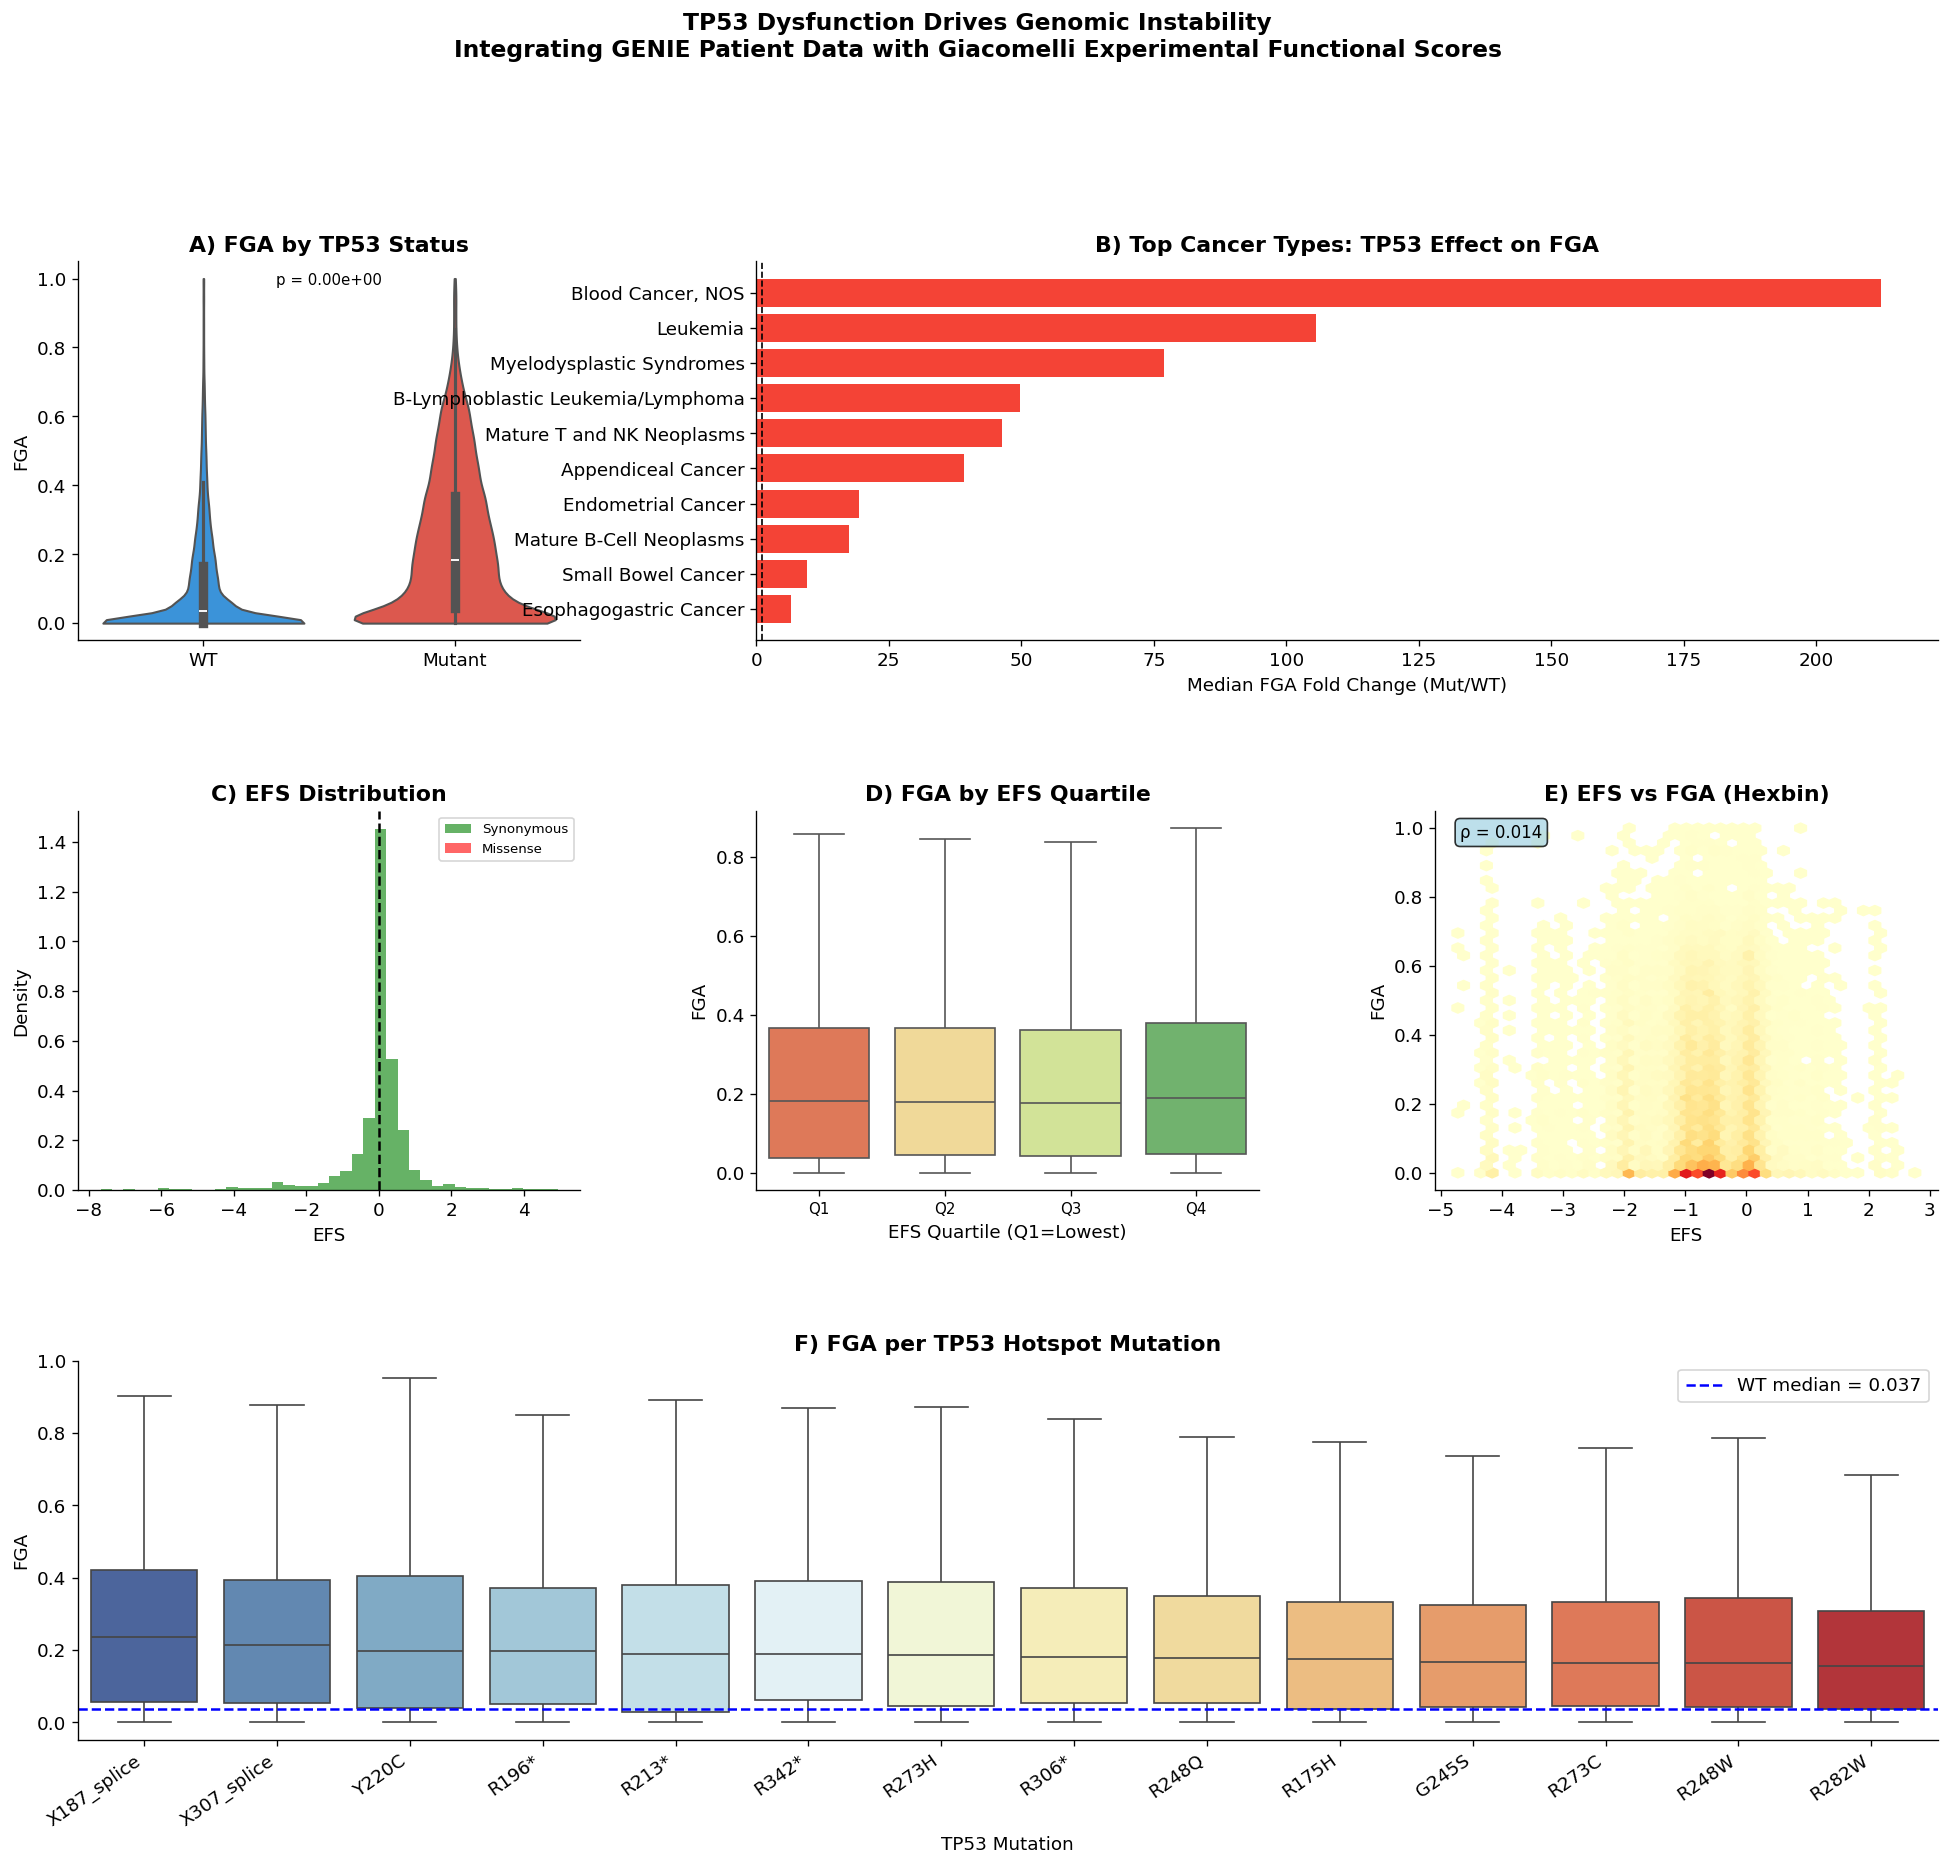

Summary figure saved.


In [31]:
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Panel A: FGA by TP53 status (violin) ---
ax_a = fig.add_subplot(gs[0, 0])
sns.violinplot(data=plot_data, x='TP53_mut_simple', y='FGA',
               order=order, palette=palette, inner='box', cut=0, ax=ax_a)
ax_a.set_title('A) FGA by TP53 Status', fontweight='bold')
ax_a.set_xlabel(''); ax_a.set_ylabel('FGA')
ax_a.annotate(f'p = {pval:.2e}', xy=(0.5, 0.97), xycoords='axes fraction',
              ha='center', va='top', fontsize=9)

# --- Panel B: Top cancer types fold change ---
ax_b = fig.add_subplot(gs[0, 1:])
top10 = cancer_stats.head(10)
colors_b = ['#F44336' if sig else '#BDBDBD' for sig in top10['significant']]
ax_b.barh(top10['Cancer Type'], top10['FGA_fold_change'], color=colors_b)
ax_b.axvline(x=1, color='black', linestyle='--', linewidth=1)
ax_b.set_xlabel('Median FGA Fold Change (Mut/WT)')
ax_b.set_title('B) Top Cancer Types: TP53 Effect on FGA', fontweight='bold')
ax_b.invert_yaxis()

# --- Panel C: EFS distribution ---
ax_c = fig.add_subplot(gs[1, 0])
syn_efs = gia_counts.loc[syn_mask, 'EFS']
mis_efs = gia_counts.loc[gia_counts['Variant_group'].str.lower().str.contains('mis', na=False), 'EFS']
ax_c.hist(syn_efs, bins=40, alpha=0.6, color='green', label='Synonymous', density=True)
ax_c.hist(mis_efs, bins=40, alpha=0.6, color='red', label='Missense', density=True)
ax_c.axvline(x=0, color='black', linestyle='--')
ax_c.set_xlabel('EFS'); ax_c.set_ylabel('Density')
ax_c.set_title('C) EFS Distribution', fontweight='bold')
ax_c.legend(fontsize=8)

# --- Panel D: EFS quartile vs FGA ---
ax_d = fig.add_subplot(gs[1, 1])
sns.boxplot(data=efs_fga, x='EFS_quartile', y='FGA',
            order=order_q, palette='RdYlGn',
            showfliers=False, ax=ax_d)
ax_d.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'], fontsize=9)
ax_d.set_xlabel('EFS Quartile (Q1=Lowest)'); ax_d.set_ylabel('FGA')
ax_d.set_title('D) FGA by EFS Quartile', fontweight='bold')

# --- Panel E: EFS-FGA scatter (hexbin) ---
ax_e = fig.add_subplot(gs[1, 2])
ax_e.hexbin(efs_fga['EFS_final'], efs_fga['FGA'], gridsize=40, cmap='YlOrRd', mincnt=1)
ax_e.set_xlabel('EFS'); ax_e.set_ylabel('FGA')
ax_e.set_title('E) EFS vs FGA (Hexbin)', fontweight='bold')
ax_e.annotate(f'ρ = {rho:.3f}', xy=(0.05, 0.93), xycoords='axes fraction', fontsize=10,
              bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# --- Panel F: Hotspot mutations FGA ---
ax_f = fig.add_subplot(gs[2, :])
df_top_sorted = df_top.copy()
sns.boxplot(data=df_top_sorted, x='TP53_mutation', y='FGA', order=mut_order,
            palette='RdYlBu_r', showfliers=False, ax=ax_f)
ax_f.axhline(y=wt_fga.median(), color='blue', linestyle='--', linewidth=1.5, label=f'WT median = {wt_fga.median():.3f}')
ax_f.set_xticklabels(ax_f.get_xticklabels(), rotation=35, ha='right')
ax_f.set_title('F) FGA per TP53 Hotspot Mutation', fontweight='bold')
ax_f.set_xlabel('TP53 Mutation'); ax_f.set_ylabel('FGA')
ax_f.legend()

fig.suptitle('TP53 Dysfunction Drives Genomic Instability\nIntegrating GENIE Patient Data with Giacomelli Experimental Functional Scores',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig('figures/summary_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary figure saved.')

## 14. Results Summary & Conclusions

In [32]:
print('='*65)
print('RESULTS SUMMARY')
print('='*65)
print()
print(f'Dataset: AACR GENIE v19.0')
print(f'  Total samples analysed: {len(df_analysis):,}')
print(f'  TP53-mutant samples:    {(df_analysis["TP53_mut_simple"]=="Mutant").sum():,}')
print(f'  TP53-wildtype samples:  {(df_analysis["TP53_mut_simple"]=="WT").sum():,}')
print()
print('Question 1: Do TP53-mutant tumors have higher FGA?')
print(f'  TP53 Mutant median FGA: {mutant_fga.median():.4f}')
print(f'  TP53 WT median FGA:     {wt_fga.median():.4f}')
print(f'  Fold change:            {mutant_fga.median()/wt_fga.median():.2f}x')
print(f'  Mann-Whitney p:         {pval:.2e}')
print(f'  Answer: YES — highly significant')
print()
print('Question 2: EFS-FGA correlation?')
print(f'  Spearman rho = {rho:.4f}, p = {p_corr:.2e}')
print(f'  Samples analysed: {len(efs_fga):,}')
print(f'  Answer: {"YES" if rho < 0 else "Weak/No"} — EFS and FGA are {"negatively" if rho < 0 else "positively"} correlated')
print()
print('Question 3: Cancer types with strongest effect?')
print(cancer_stats.head(5)[['Cancer Type', 'FGA_fold_change', 'p_adj']].to_string(index=False))
print()
print('Hypothesis: lowest EFS → highest FGA')
q1_fga = efs_fga.loc[efs_fga['EFS_quartile'] == 'Q1\n(Lowest)', 'FGA'].median()
q4_fga = efs_fga.loc[efs_fga['EFS_quartile'] == 'Q4\n(Highest)', 'FGA'].median()
print(f'  Q1 (lowest EFS) median FGA: {q1_fga:.4f}')
print(f'  Q4 (highest EFS) median FGA: {q4_fga:.4f}')
print(f'  Kruskal-Wallis p = {kw_p:.2e}')
print(f'  Hypothesis {"SUPPORTED" if q1_fga > q4_fga else "NOT SUPPORTED"}')
print()
print('='*65)

RESULTS SUMMARY

Dataset: AACR GENIE v19.0
  Total samples analysed: 100,418
  TP53-mutant samples:    35,357
  TP53-wildtype samples:  65,061

Question 1: Do TP53-mutant tumors have higher FGA?
  TP53 Mutant median FGA: 0.1820
  TP53 WT median FGA:     0.0366
  Fold change:            4.97x
  Mann-Whitney p:         0.00e+00
  Answer: YES — highly significant

Question 2: EFS-FGA correlation?
  Spearman rho = 0.0136, p = 1.10e-02
  Samples analysed: 35,000
  Answer: Weak/No — EFS and FGA are positively correlated

Question 3: Cancer types with strongest effect?
                      Cancer Type  FGA_fold_change        p_adj
                Blood Cancer, NOS       212.333333 1.556290e-09
                         Leukemia       105.600000 1.232580e-89
        Myelodysplastic Syndromes        77.000000 9.853530e-16
B-Lymphoblastic Leukemia/Lymphoma        49.850000 2.676407e-08
        Mature T and NK Neoplasms        46.400000 4.549819e-14

Hypothesis: lowest EFS → highest FGA
  Q1 (low